# Problem set 3

The Niño3.4 index is defined as the sea surface temperature anomaly relative to the mean annual cycle averaged over the region 170°W-240°W, 5°S-5°N. In this assignment, you will use the provided csv data files (monthly SST anomalies in Niño3.4) to calculate and compare basic statistics of El Niño-Southern Oscillation (ENSO) activity as represented by this index in observations and a set of nine model simulations. The model simulations differ only in the amount of CO<sub>2</sub> in the atmosphere, so differences in ENSO variability across the simulations primarily indicate the influence of changes in CO<sub>2</sub> .

**(a)** ENSO variability is typically tracked using the [Oceanic Niño Index](https://www.climate.gov/news-features/understanding-climate/climate-variability-oceanic-nino-index) (ONI), defined as the three-month running mean sea surface temperature anomaly in the Niño3.4 region. Read in the data and calculate Oceanic Niño indices for the observations and each simulation (hint: see documentation for [pandas.DataFrame.rolling](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html)). Calculate and compare the standard deviations of the ONI from each dataset. Show your results graphically, considering how to effectively distinguish the value based on observations from those based on the model simulations. How does the simulated ENSO variability change with increasing CO<sub>2</sub> across the model runs? How do the simulated values compare to the observed variability? 

ONI standard deviation summary:
             Dataset  CO2 multiplier  ONI standard deviation (°C)
ERSSTv5 observations            1.00                        0.865
                 CTL            1.00                        0.818
            1.25xCO2            1.25                        0.826
             1.5xCO2            1.50                        0.826
            1.75xCO2            1.75                        0.697
               2xCO2            2.00                        0.746
               3xCO2            3.00                        0.752
               4xCO2            4.00                        0.634
               6xCO2            6.00                        0.610
               8xCO2            8.00                        0.524


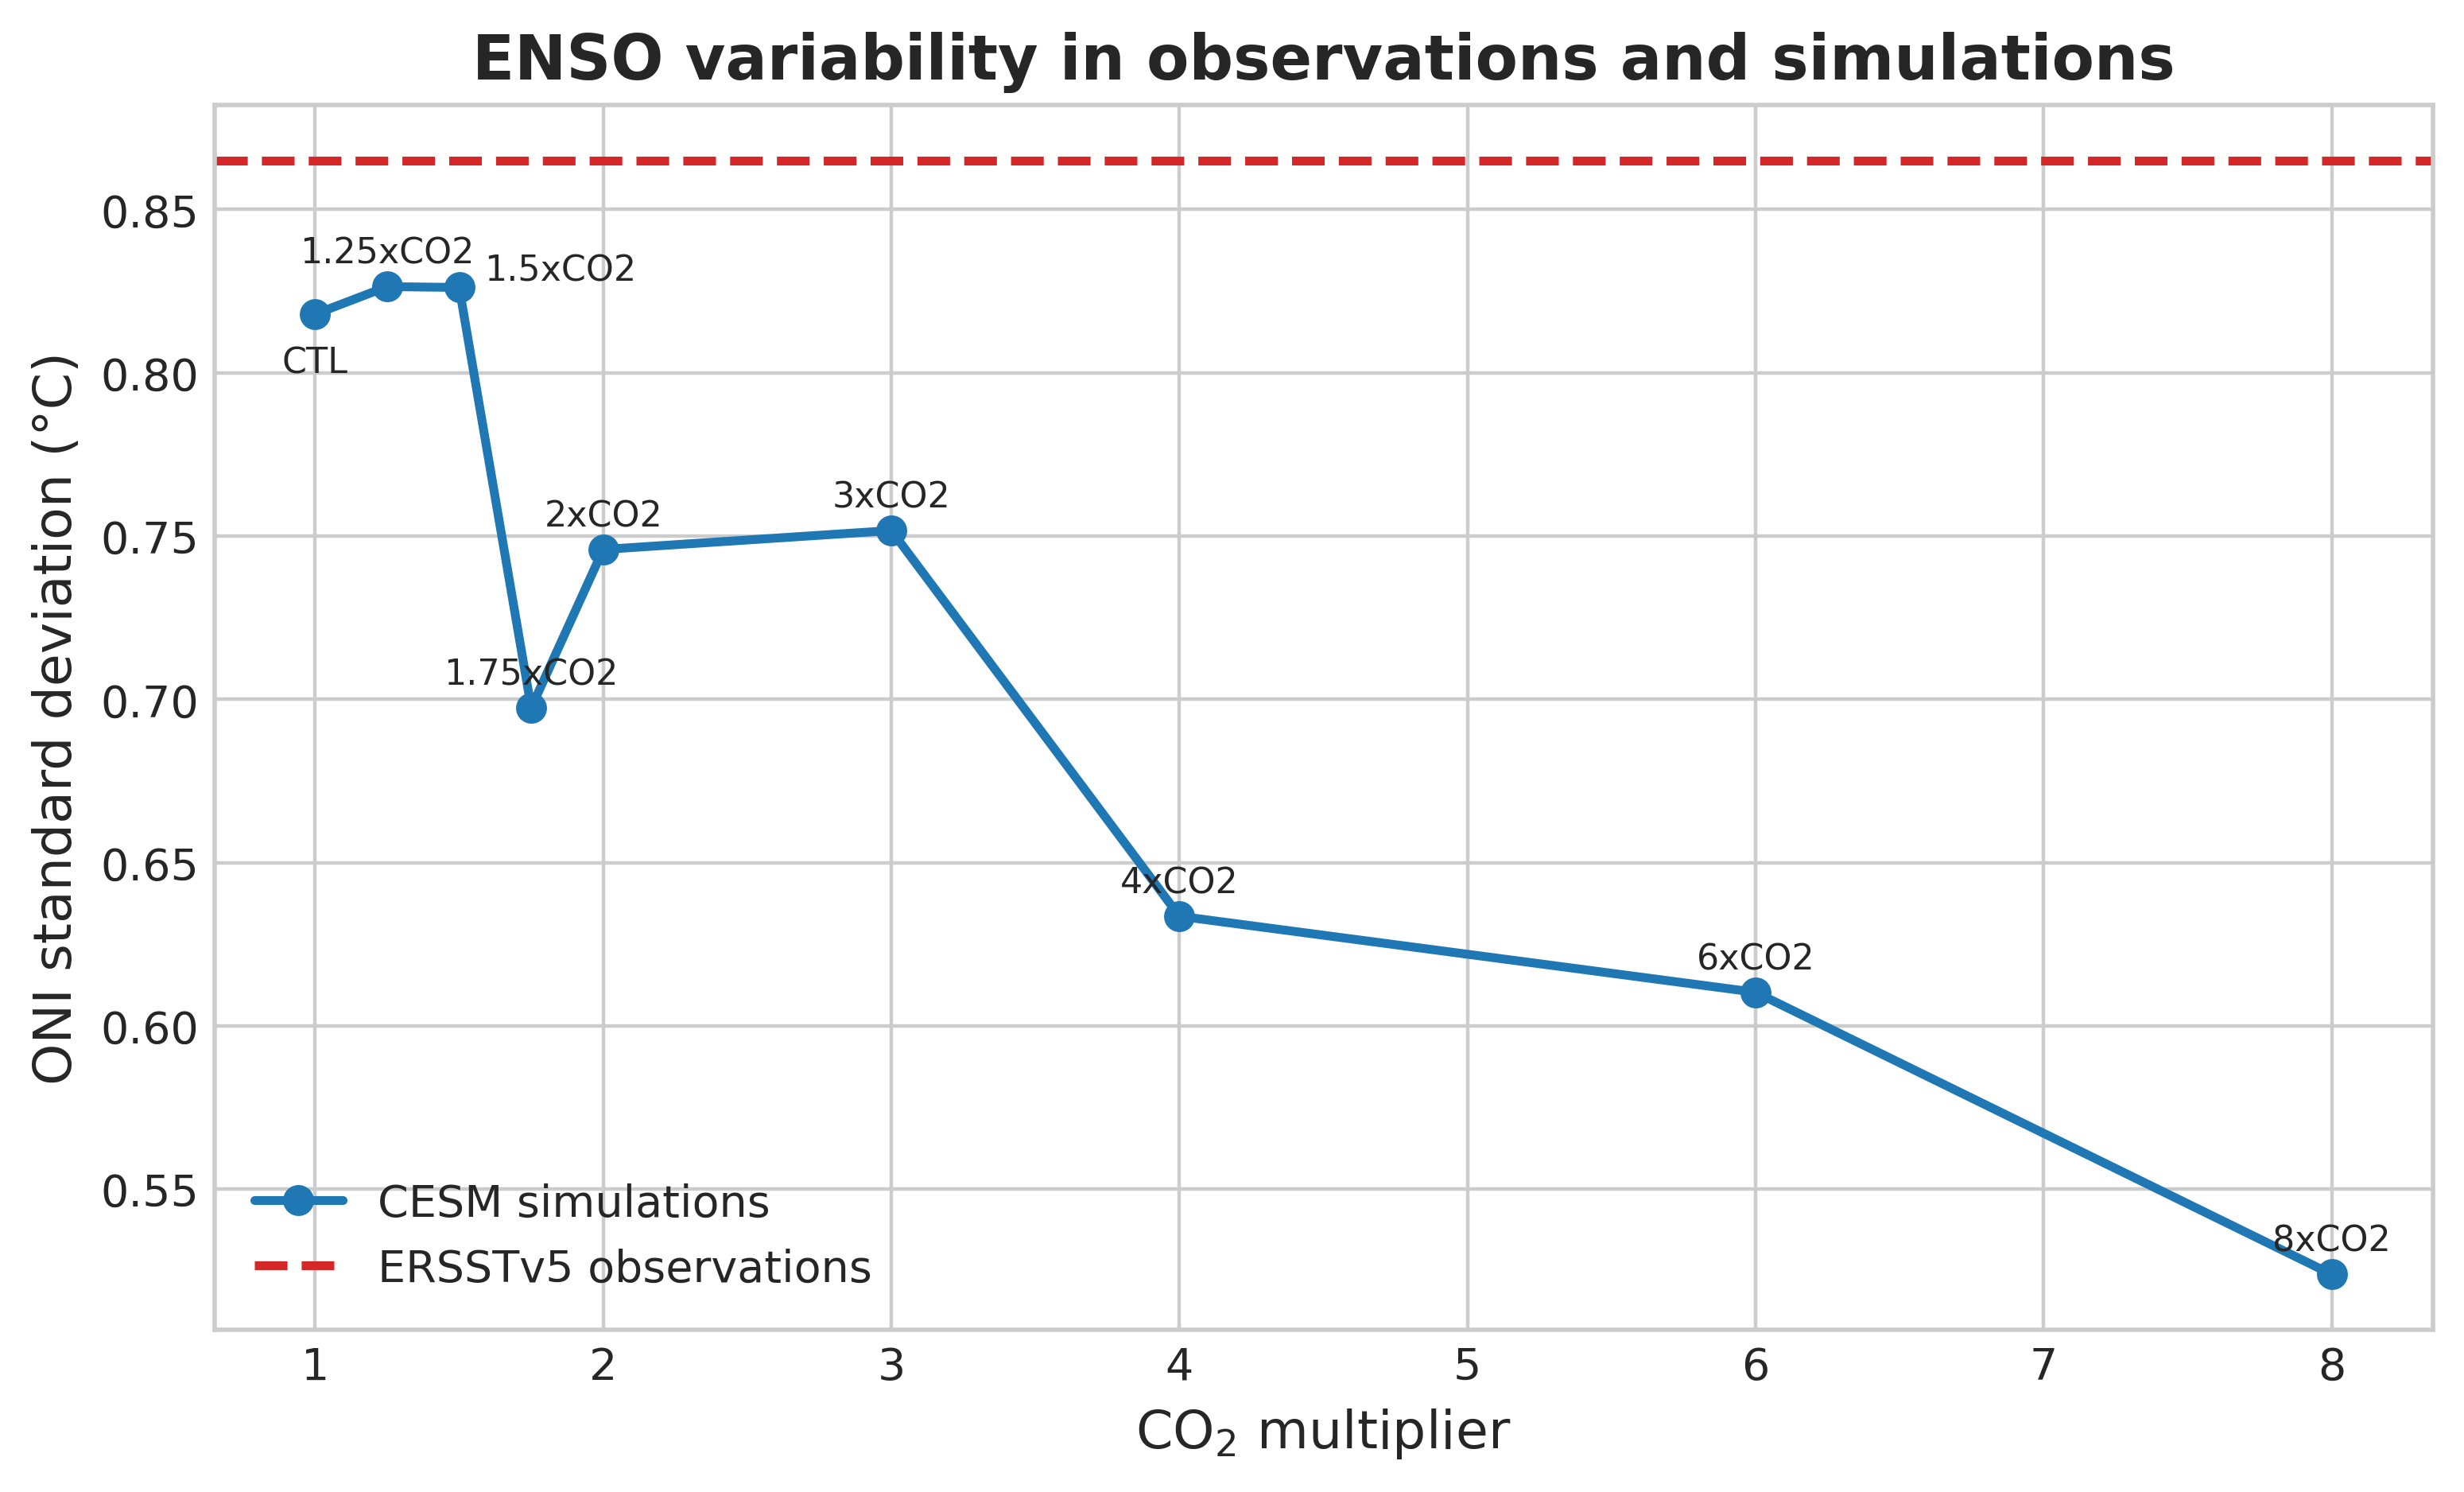


Conclusion:
- The observed ONI standard deviation is about 0.865 °C
- The simulated ENSO variability is weaker than observations in all cases, with the CTL, 1.25xCO₂, and 1.5xCO₂ being the closest
- As CO2 increases further, the simulated ENSO variability weakens overall, and 8xCO2 drops to about 0.524 °C



In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 400

data_dir = Path("data")

obs = pd.read_csv(data_dir / "ersstv5_nino34_1m_1854-2020.csv", index_col=0)
obs.index = pd.to_datetime(obs.index, format="%Y-%m-%d")

models = pd.read_csv(data_dir / "cesm1topo_nino34_1m_0151-0300.csv", index_col=0)
models.index = pd.to_datetime(models.index, format="%Y-%m-%d %H:%M:%S")

oni_obs = obs.rolling(window=3).mean()
oni_models = models.rolling(window=3).mean()

co2_levels = pd.Series(
    [1.0, 1.25, 1.5, 1.75, 2.0, 3.0, 4.0, 6.0, 8.0],
    index=models.columns,
    name="CO2 multiplier",
)

obs_std = float(oni_obs.iloc[:, 0].std())
model_std = oni_models.std()
oni_std_table = pd.concat(
    [
        pd.DataFrame(
            {
                "dataset": ["ERSSTv5 observations"],
                "co2_multiplier": [1.0],
                "oni_std": [obs_std],
            }
        ),
        pd.DataFrame(
            {
                "dataset": models.columns,
                "co2_multiplier": co2_levels.values,
                "oni_std": model_std.values,
            }
        ),
    ],
    ignore_index=True,
).rename(
    columns={
        "dataset": "Dataset",
        "co2_multiplier": "CO2 multiplier",
        "oni_std": "ONI standard deviation (°C)",
    }
)

print("ONI standard deviation summary:")
print(oni_std_table.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    co2_levels.values,  # type: ignore
    model_std.values,  # type: ignore
    marker="o",
    linewidth=2,
    color="tab:blue",
    label="CESM simulations",
)
ax.axhline(
    obs_std,
    color="tab:red",
    linestyle="--",
    linewidth=2,
    label="ERSSTv5 observations",
)

ax.text(co2_levels.values[0], model_std.values[0] - 0.02, models.columns[0], ha="center", va="bottom", fontsize=8)
ax.text(co2_levels.values[1], model_std.values[1] + 0.005, models.columns[1], ha="center", va="bottom", fontsize=8)
ax.text(co2_levels.values[2] + 0.35, model_std.values[2], models.columns[2], ha="center", va="bottom", fontsize=8)
for x, y, label in zip(co2_levels.values[3:], model_std.values[3:], models.columns[3:]):
    ax.text(x, y + 0.005, label, ha="center", va="bottom", fontsize=8)

ax.set_xlabel("CO$_2$ multiplier", fontsize=12)
ax.set_ylabel("ONI standard deviation (°C)", fontsize=12)
ax.set_title("ENSO variability in observations and simulations", fontsize=14, weight="bold")
ax.legend()
plt.show()

print(f"""
Conclusion:
- The observed ONI standard deviation is about {obs_std:.3f} °C
- The simulated ENSO variability is weaker than observations in all cases, with the CTL, 1.25xCO₂, and 1.5xCO₂ being the closest
- As CO2 increases further, the simulated ENSO variability weakens overall, and 8xCO2 drops to about {model_std['8xCO2']:.3f} °C
"""
)

**(b)** Super El Niño events are defined as having peak ONI anomalies exceeding 2°C. How many months met the super El Niño threshold in the observational record? How many of these months did each simulation produce? How does the occurrence frequency of such months change with increasing CO<sub>2</sub> in this model?

Months with ONI > 2 °C:
             Dataset  CO2 multiplier  Number of super El Niño months
ERSSTv5 observations            1.00                              20
                 CTL            1.00                              15
            1.25xCO2            1.25                              27
             1.5xCO2            1.50                              28
            1.75xCO2            1.75                              10
               2xCO2            2.00                               5
               3xCO2            3.00                               5
               4xCO2            4.00                               3
               6xCO2            6.00                               0
               8xCO2            8.00                               0


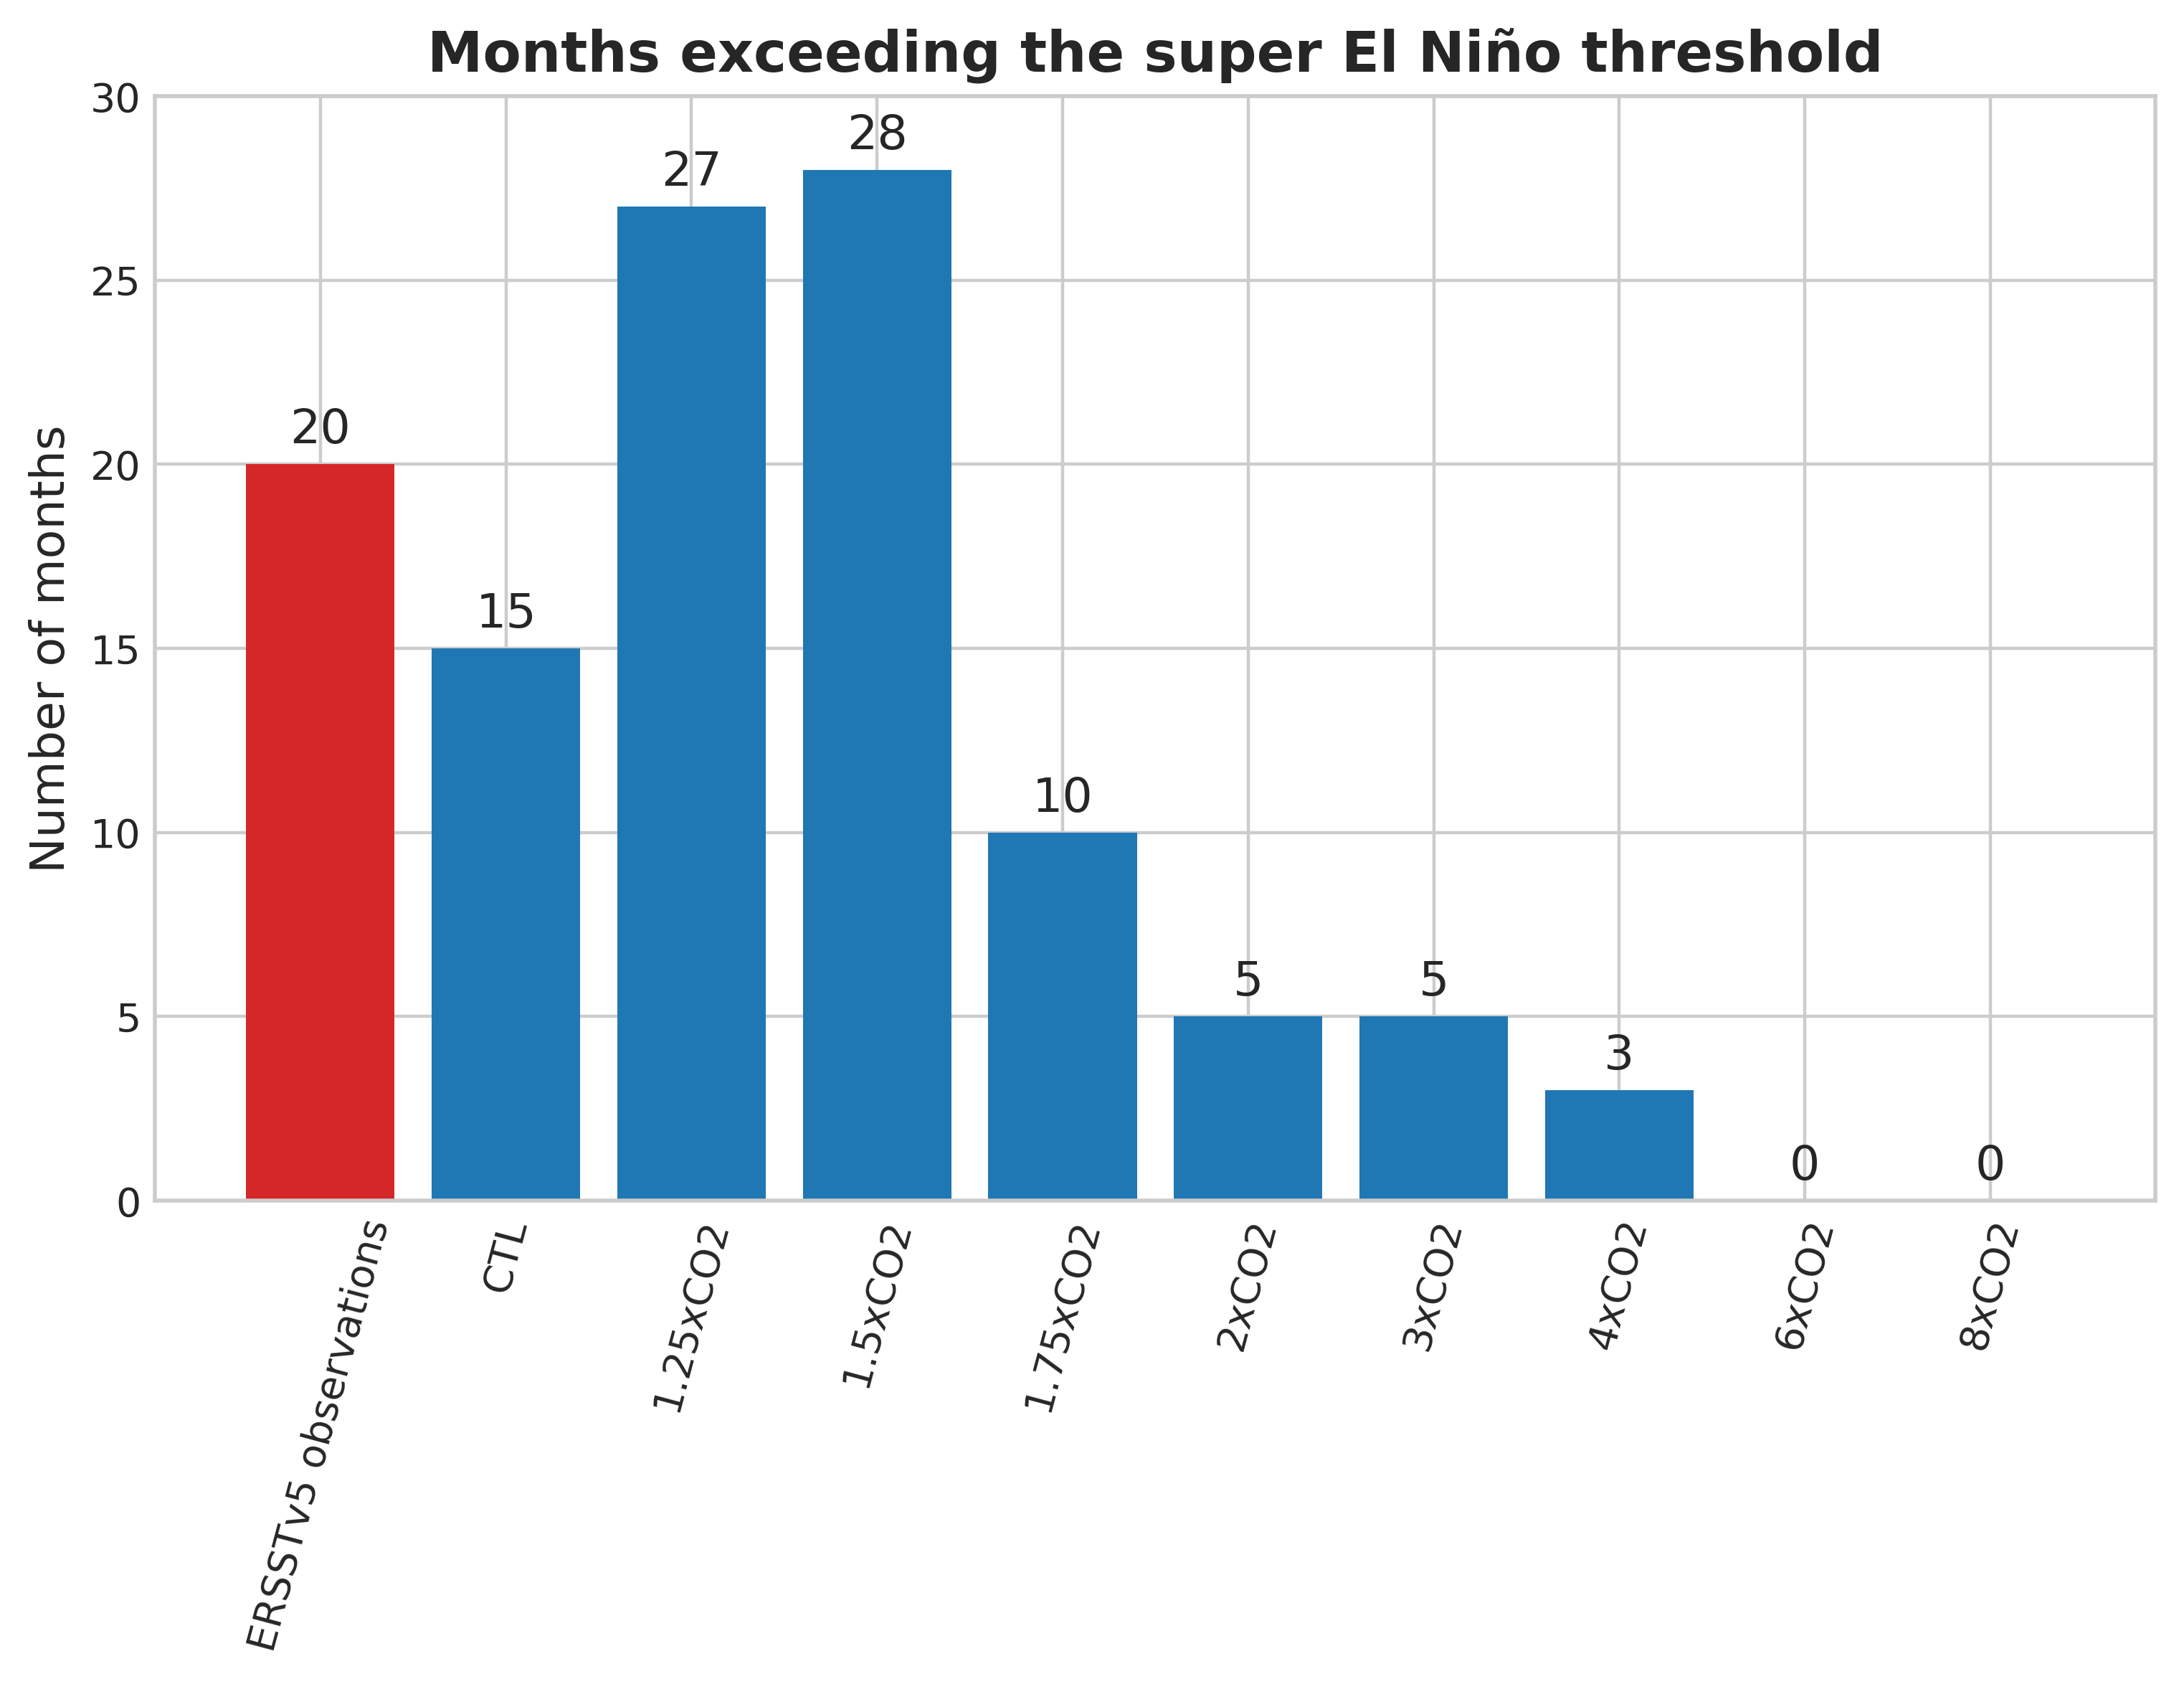


Conclusion:
- The observational record contains 20 months with ONI > 2 °C, which is the super El Niño threshold
- 1.25xCO2 and 1.5xCO2 produce 27 and 28 months, which is higher than observed
- Under higher CO2, these extreme warm events become much less frequent, and both 6xCO2 and 8xCO2 drop to 0 months



In [2]:
super_obs_months = int((oni_obs.iloc[:, 0] > 2.0).sum())
super_model_months = oni_models.gt(2.0).sum().astype(int)
super_month_table = pd.concat(
    [
        pd.DataFrame(
            {
                "dataset": ["ERSSTv5 observations"],
                "co2_multiplier": [1.0],
                "super_months": [super_obs_months],
            }
        ),
        pd.DataFrame(
            {
                "dataset": models.columns,
                "co2_multiplier": co2_levels.values,
                "super_months": super_model_months.values,
            }
        ),
    ],
    ignore_index=True,
).rename(
    columns={
        "dataset": "Dataset",
        "co2_multiplier": "CO2 multiplier",
        "super_months": "Number of super El Niño months",
    }
)

print("Months with ONI > 2 °C:")
print(super_month_table.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
plot_labels = ["ERSSTv5 observations", *models.columns]
bars = ax.bar(
    plot_labels,
    super_month_table["Number of super El Niño months"],
    color=["tab:red"] + ["tab:blue"] * len(models.columns),
)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.3, str(int(height)), ha='center', va='bottom', fontsize=12)

ax.set_ylabel("Number of months", fontsize=12)
ax.set_ylim(0, 30)
ax.set_title("Months exceeding the super El Niño threshold", fontsize=14, weight="bold")
ax.tick_params(axis="x", rotation=75)
plt.show()


print(f"""
Conclusion:
- The observational record contains {super_obs_months} months with ONI > 2 °C, which is the super El Niño threshold
- 1.25xCO2 and 1.5xCO2 produce {super_model_months['1.25xCO2']} and {super_model_months['1.5xCO2']} months, which is higher than observed
- Under higher CO2, these extreme warm events become much less frequent, and both 6xCO2 and 8xCO2 drop to 0 months
"""
)

**(c)** El Niño events are defined as periods for which the ONI exceeds 0.5°C for at least five consecutive months. Use [pandas.DataFrame.groupby](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.groupby.html) to identify and count the number of El Niño events in the ERSST observational record (hint: in Python, the numerical value of the boolean True is 1 and the numerical value of False is 0, and you can construct a cumulative sum using [pandas.DataFrame.cumsum](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.cumsum.html)). How many El Niño events occurred during this period? How many of them met the super El Niño threshold?

In [3]:
obs_oni = oni_obs.iloc[:, 0]
is_el_nino = obs_oni > 0.5

# Generate unique group IDs for consecutive periods of identical states
group_id = is_el_nino.ne(is_el_nino.shift()).cumsum()

event_months = pd.DataFrame(
    {
        "is_el_nino": is_el_nino,
        "oni": obs_oni,
        "group": group_id,
    }
)

el_nino_events = (
    event_months.groupby("group")
    .agg(
        is_el_nino=("is_el_nino", "first"),
        start=("oni", lambda x: x.index[0]),
        end=("oni", lambda x: x.index[-1]),
        duration_months=("oni", "size"),
        peak_oni=("oni", "max"),
    )
    .query("is_el_nino and duration_months >= 5")
    .copy()
)

el_nino_events["start"] = el_nino_events["start"].dt.strftime("%Y-%m")
el_nino_events["end"] = el_nino_events["end"].dt.strftime("%Y-%m")
el_nino_events["peak_oni"] = el_nino_events["peak_oni"].round(3)
el_nino_events["is_super"] = el_nino_events["peak_oni"] > 2.0

super_event_count = int(el_nino_events["is_super"].sum())
event_display = el_nino_events[["start", "end", "duration_months", "peak_oni", "is_super"]].rename(
    columns={
        "start": "Start",
        "end": "End",
        "duration_months": "Duration (months)",
        "peak_oni": "Peak ONI (°C)",
        "is_super": "Super event",
    }
).rename_axis("Event ID")

print("Observed El Niño events:")
print(event_display.to_string())
print()
print(f"Total event count: {len(el_nino_events)}")
print(f"Super El Niño event count: {super_event_count}")

print(
f"""
Conclusion:
- A total of {len(el_nino_events)} El Niño events are identified in the ERSSTv5 record
- Among them, {super_event_count} events have peak ONI above 2 °C and can be classified as super El Niño events
- The super events mainly correspond to 1877-78, 1888-89, 1982-83, 1997-98, and 2015-16
"""
)

Observed El Niño events:
            Start      End  Duration (months)  Peak ONI (°C)  Super event
Event ID                                                                 
6         1877-07  1878-06                 12          2.428         True
10        1888-09  1889-05                  9          2.098         True
12        1896-08  1897-03                  8          1.482        False
14        1899-12  1900-07                  8          1.127        False
16        1902-06  1903-03                 10          1.673        False
18        1905-02  1906-02                 13          1.097        False
20        1911-12  1912-04                  5          0.963        False
24        1914-09  1915-06                 10          1.050        False
26        1918-11  1919-03                  5          1.508        False
32        1925-12  1926-05                  6          1.041        False
34        1930-10  1931-04                  7          1.029        False
38        194

**(d)** Previous studies have shown that at least 1000 years of simulation time are required to reliably remove the influences of internal variability from simulated ENSO statistics. Each simulation in this example is only 150 years long and the observational record is not much longer. How does this influence your interpretation of the results?

These results are better interpreted as suggestive patterns rather than fully definitive ENSO forced responses.

- Each simulation is only 150 years long, and the observational record is only modestly longer, so internal variability can still strongly affect the estimated standard deviations and event counts.

- Rare extremes are especially sensitive to the sample size, so differences in the number of super El Niño months may partly reflect sampling chance rather than a clean direct CO2-forced signal.

- The broad pattern in this notebook is that high-CO2 simulations tend to have weaker ENSO variability and fewer super El Niño months, but nearby experiments should not be over-interpreted one by one.

- To separate the forced response from internal variability more confidently, longer simulations or, ideally, multiple ensemble members at each CO2 level would be needed.